# EDA completo en Python con un dataset famoso

Este notebook implementa, paso a paso, lo que vimos en la presentación sobre **Análisis Exploratorio de Datos (EDA)**.

## Dataset elegido
Usaremos el dataset **Iris**, uno de los más famosos en ciencia de datos.  
Como es un dataset muy limpio, le agregaremos algunos elementos de forma pedagógica para practicar un EDA más realista:

- variables categóricas derivadas
- una variable de fecha
- algunos valores faltantes
- algunos duplicados
- un par de outliers intencionales

> Objetivo pedagógico: aprender **qué revisar, qué mostrar y cómo interpretar** un EDA.

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

RANDOM_STATE = 52
rng = np.random.default_rng(RANDOM_STATE)

## 1. Cargar y preparar los datos

Primero cargamos el dataset base desde `scikit-learn` y luego creamos algunas columnas extra para enriquecer el análisis.

In [3]:
iris = load_iris(as_frame=True)
df = iris.frame.copy()

# Renombrar columnas para que queden más legibles
df = df.rename(columns={
    "sepal length (cm)": "sepal_length",
    "sepal width (cm)": "sepal_width",
    "petal length (cm)": "petal_length",
    "petal width (cm)": "petal_width",
    "target": "species_id"
})

df["species"] = df["species_id"].map(dict(enumerate(iris.target_names)))

# Variables derivadas útiles para EDA
df["petal_area"] = df["petal_length"] * df["petal_width"]
df["sepal_area"] = df["sepal_length"] * df["sepal_width"]

df["petal_size"] = pd.qcut(
    df["petal_area"],
    q=3,
    labels=["small", "medium", "large"]
)

# Fecha sintética para practicar EDA temporal
df["observation_date"] = pd.date_range("2024-01-01", periods=len(df), freq="D")

# Inyectar algunos faltantes de forma pedagógica
missing_idx_1 = rng.choice(df.index, size=8, replace=False)
missing_idx_2 = rng.choice(df.index, size=6, replace=False)
df.loc[missing_idx_1, "sepal_width"] = np.nan
df.loc[missing_idx_2, "petal_size"] = np.nan

# Inyectar 2 outliers pedagógicos
outlier_idx = rng.choice(df.index, size=2, replace=False)
df.loc[outlier_idx, "sepal_length"] = df["sepal_length"].max() * 1.8
df.loc[outlier_idx, "petal_width"] = df["petal_width"].max() * 1.7

# Agregar duplicados pedagógicos
df = pd.concat([df, df.iloc[[5, 25]]], ignore_index=True)

df.head()

,sepal_length,sepal_width,petal_length,petal_width,species_id,species,petal_area,sepal_area,petal_size,observation_date
0,5.100,NaN,1.400,0.200,0,setosa,0.280,17.850,small,2024-01-01
1,4.900,3.000,1.400,0.200,0,setosa,0.280,14.700,small,2024-01-02
2,4.700,3.200,1.300,0.200,0,setosa,0.260,15.040,NaN,2024-01-03
3,4.600,3.100,1.500,0.200,0,setosa,0.300,14.260,small,2024-01-04
4,5.000,3.600,1.400,0.200,0,setosa,0.280,18.000,small,2024-01-05


## 2. Entender el problema y la unidad de análisis

Antes del EDA conviene responder:

- ¿Qué representa cada fila?
- ¿Qué representa cada columna?
- ¿Hay una variable objetivo?
- ¿Queremos describir, comparar grupos o preparar un modelo?

En este caso:
- **Cada fila** representa una flor observada.
- **La variable objetivo** puede ser `species`.
- El EDA buscará entender estructura, calidad, distribuciones y diferencias entre especies.

## 3. Primer vistazo al dataset

Acá revisamos tamaño, tipos, muestra de registros y estadísticas básicas.

In [4]:
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")
print("\nTipos de datos:")
display(df.dtypes.to_frame("dtype"))

print("\nPrimeras filas:")
display(df.head())

print("\nEstadísticas descriptivas:")
display(df.describe(include="all").T)

Filas: 152
Columnas: 10

Tipos de datos:


,dtype
sepal_length,float64
sepal_width,float64
petal_length,float64
petal_width,float64
species_id,int64
species,str
petal_area,float64
sepal_area,float64
petal_size,category
observation_date,datetime64[us]



Primeras filas:


,sepal_length,sepal_width,petal_length,petal_width,species_id,species,petal_area,sepal_area,petal_size,observation_date
0,5.100,NaN,1.400,0.200,0,setosa,0.280,17.850,small,2024-01-01
1,4.900,3.000,1.400,0.200,0,setosa,0.280,14.700,small,2024-01-02
2,4.700,3.200,1.300,0.200,0,setosa,0.260,15.040,NaN,2024-01-03
3,4.600,3.100,1.500,0.200,0,setosa,0.300,14.260,small,2024-01-04
4,5.000,3.600,1.400,0.200,0,setosa,0.280,18.000,small,2024-01-05



Estadísticas descriptivas:


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
sepal_length,152.000,NaN,NaN,NaN,5.956,4.300,5.100,5.800,6.400,14.220,1.261
sepal_width,144.000,NaN,NaN,NaN,3.069,2.000,2.800,3.000,3.325,4.400,0.437
petal_length,152.000,NaN,NaN,NaN,3.730,1.000,1.600,4.300,5.100,6.900,1.770
petal_width,152.000,NaN,NaN,NaN,1.241,0.100,0.300,1.300,1.800,4.250,0.832
species_id,152.000,NaN,NaN,NaN,0.987,0.000,0.000,1.000,2.000,2.000,0.822
species,152,3,setosa,52,NaN,NaN,NaN,NaN,NaN,NaN,NaN
petal_area,152.000,NaN,NaN,NaN,5.724,0.110,0.420,5.590,9.690,15.870,4.720
sepal_area,152.000,NaN,NaN,NaN,17.826,10.000,15.655,17.660,20.400,30.020,3.358
petal_size,146,3,small,49,NaN,NaN,NaN,NaN,NaN,NaN,NaN
observation_date,152,NaN,NaN,NaN,2024-03-14 17:12:37.894736,2024-01-01 00:00:00,2024-02-05 18:00:00,2024-03-14 12:00:00,2024-04-21 06:00:00,2024-05-29 00:00:00,NaN


## 4. Calidad de datos

Un EDA siempre debe incluir al menos:

- valores faltantes
- duplicados
- tipos de dato
- categorías inconsistentes
- valores fuera de rango o sospechosos

In [5]:
missing = (
    df.isna()
      .sum()
      .to_frame("n_missing")
      .assign(pct_missing=lambda x: 100 * x["n_missing"] / len(df))
      .sort_values("pct_missing", ascending=False)
)

duplicates = df.duplicated().sum()

display(missing)
print(f"Registros duplicados: {duplicates}")

,n_missing,pct_missing
sepal_width,8,5.263
petal_size,6,3.947
sepal_length,0,0.000
petal_length,0,0.000
petal_width,0,0.000
species_id,0,0.000
species,0,0.000
petal_area,0,0.000
sepal_area,0,0.000
observation_date,0,0.000


Registros duplicados: 2


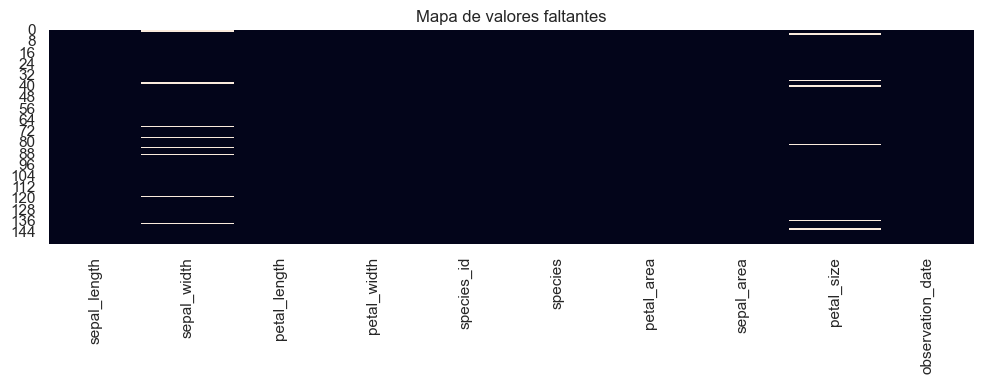

In [6]:
plt.figure(figsize=(10, 4))
sns.heatmap(df.isna(), cbar=False)
plt.title("Mapa de valores faltantes")
plt.tight_layout()
plt.show()

### Interpretación esperada
En este punto deberíamos poder responder:

- qué columnas tienen faltantes
- si el porcentaje es alto o bajo
- si hay duplicados
- si el problema de calidad parece manejable

## 5. Tratamiento inicial de calidad

No siempre hay que transformar inmediatamente en el EDA, pero sí conviene mostrar qué haríamos.

En este ejemplo:
- eliminaremos duplicados
- imputaremos `sepal_width` con la mediana
- imputaremos `petal_size` con la moda

In [7]:
df_eda = df.copy()

# Eliminar duplicados
df_eda = df_eda.drop_duplicates().reset_index(drop=True)

# Imputación
num_imputer = SimpleImputer(strategy="median")
cat_imputer = SimpleImputer(strategy="most_frequent")

df_eda["sepal_width"] = num_imputer.fit_transform(df_eda[["sepal_width"]]).ravel()
df_eda["petal_size"] = cat_imputer.fit_transform(df_eda[["petal_size"]]).ravel()

print("Después del tratamiento:")
print(f"Filas: {df_eda.shape[0]}")
print(f"Duplicados: {df_eda.duplicated().sum()}")
print("\nFaltantes restantes:")
display(df_eda.isna().sum().to_frame("n_missing"))

Después del tratamiento:
Filas: 150
Duplicados: 0

Faltantes restantes:


,n_missing
sepal_length,0
sepal_width,0
petal_length,0
petal_width,0
species_id,0
species,0
petal_area,0
sepal_area,0
petal_size,0
observation_date,0


## 6. Variables numéricas: qué mostrar

Para variables numéricas normalmente mostramos:

- tendencia central: media, mediana
- dispersión: desviación estándar, rango
- forma de la distribución
- posibles outliers

In [8]:
numeric_cols = df_eda.select_dtypes(include=np.number).columns.tolist()
numeric_cols

['sepal_length',
 'sepal_width',
 'petal_length',
 'petal_width',
 'species_id',
 'petal_area',
 'sepal_area']

In [9]:
display(df_eda[numeric_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
sepal_length,150.000,5.966,1.266,4.300,5.100,5.800,6.400,14.220
sepal_width,150.000,3.061,0.423,2.000,2.800,3.000,3.300,4.400
petal_length,150.000,3.758,1.765,1.000,1.600,4.350,5.100,6.900
petal_width,150.000,1.253,0.830,0.100,0.300,1.300,1.800,4.250
species_id,150.000,1.000,0.819,0.000,0.000,1.000,2.000,2.000
petal_area,150.000,5.794,4.712,0.110,0.420,5.615,9.690,15.870
sepal_area,150.000,17.823,3.362,10.000,15.660,17.660,20.325,30.020


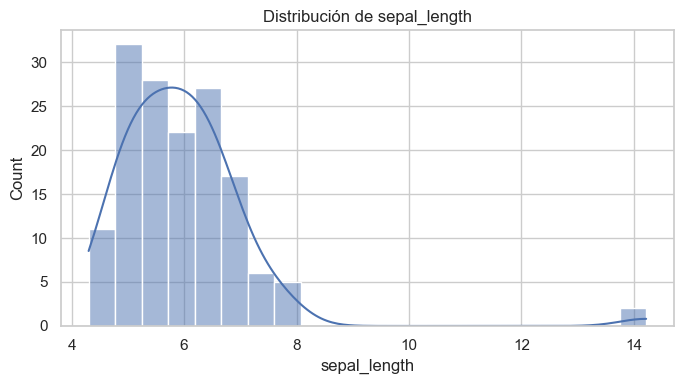

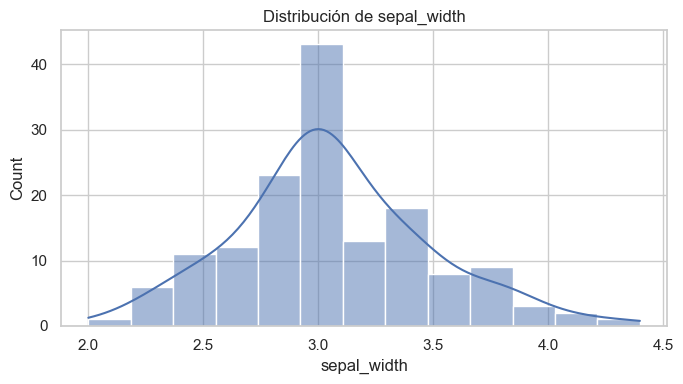

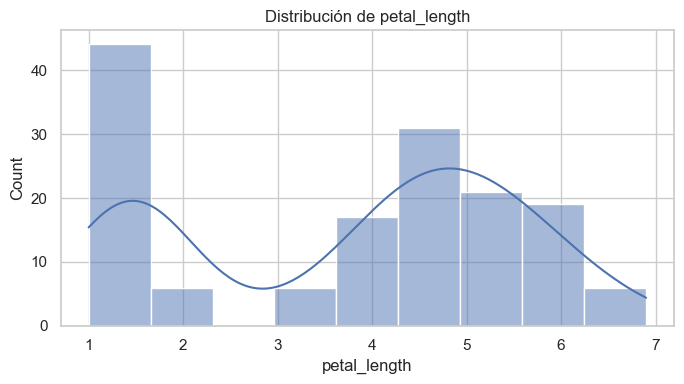

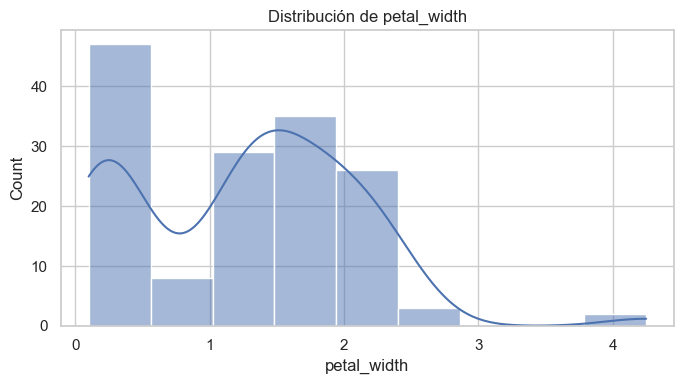

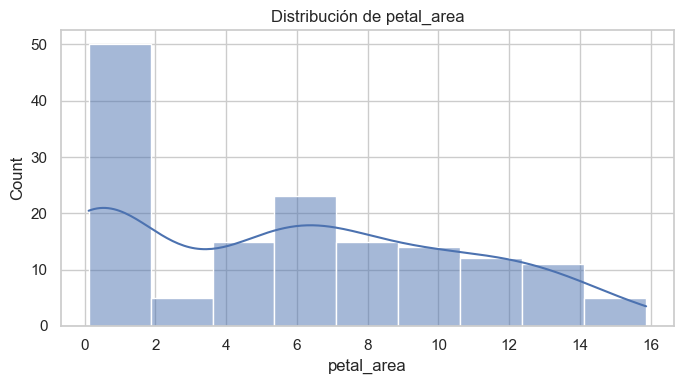

In [10]:
for col in ["sepal_length", "sepal_width", "petal_length", "petal_width", "petal_area"]:
    plt.figure(figsize=(7, 4))
    sns.histplot(df_eda[col], kde=True)
    plt.title(f"Distribución de {col}")
    plt.tight_layout()
    plt.show()

### Qué interpretar aquí
- simetría o asimetría
- concentración de valores
- colas largas
- multimodalidad
- posibles observaciones anómalas

## 7. Variables categóricas: qué mostrar

Para variables categóricas interesa revisar:

- frecuencia por categoría
- categorías dominantes
- categorías raras
- errores de escritura o codificación

In [11]:
categorical_cols = df_eda.select_dtypes(include=["object", "category"]).columns.tolist()
categorical_cols

['species', 'petal_size']

In [12]:
for col in categorical_cols:
    print(f"\nFrecuencias de {col}:")
    display(df_eda[col].value_counts(dropna=False).to_frame("count"))


Frecuencias de species:


,count
species,
setosa,50
versicolor,50
virginica,50



Frecuencias de petal_size:


,count
petal_size,
medium,55
large,48
small,47


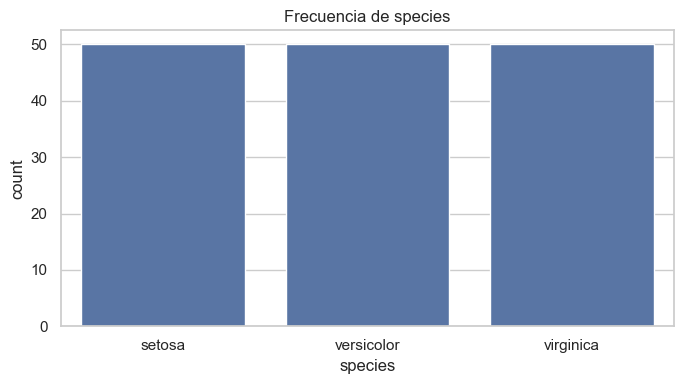

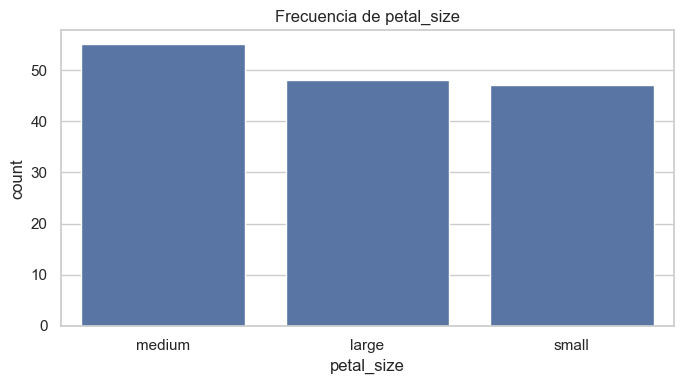

In [13]:
for col in ["species", "petal_size"]:
    plt.figure(figsize=(7, 4))
    order = df_eda[col].value_counts().index
    sns.countplot(data=df_eda, x=col, order=order)
    plt.title(f"Frecuencia de {col}")
    plt.tight_layout()
    plt.show()

## 8. Variables temporales

Cuando hay fechas, conviene revisar:

- rango temporal
- frecuencia de observaciones
- vacíos
- tendencias
- posibles cambios abruptos

In [14]:
print("Rango temporal:")
print(df_eda["observation_date"].min(), "->", df_eda["observation_date"].max())

daily_counts = (
    df_eda.groupby("observation_date")
          .size()
          .rename("n_obs")
          .reset_index()
)

display(daily_counts.head())

Rango temporal:
2024-01-01 00:00:00 -> 2024-05-29 00:00:00


,observation_date,n_obs
0,2024-01-01,1
1,2024-01-02,1
2,2024-01-03,1
3,2024-01-04,1
4,2024-01-05,1


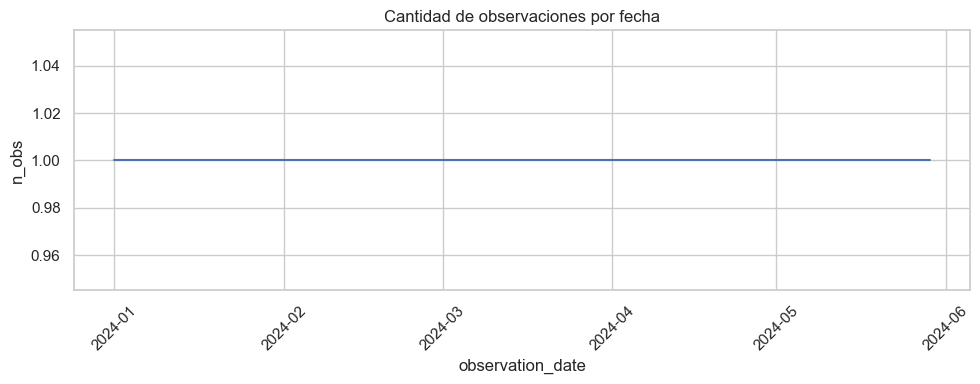

In [15]:
plt.figure(figsize=(10, 4))
sns.lineplot(data=daily_counts, x="observation_date", y="n_obs")
plt.title("Cantidad de observaciones por fecha")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 9. Detección de outliers

Los outliers pueden ser:
- errores de captura
- casos reales poco comunes
- señales importantes del negocio

No siempre deben eliminarse. Primero deben investigarse.

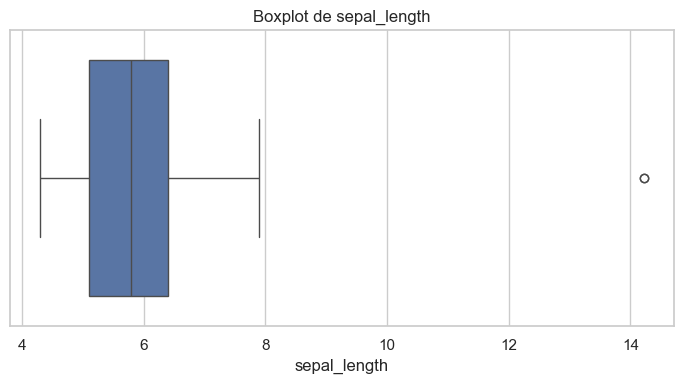

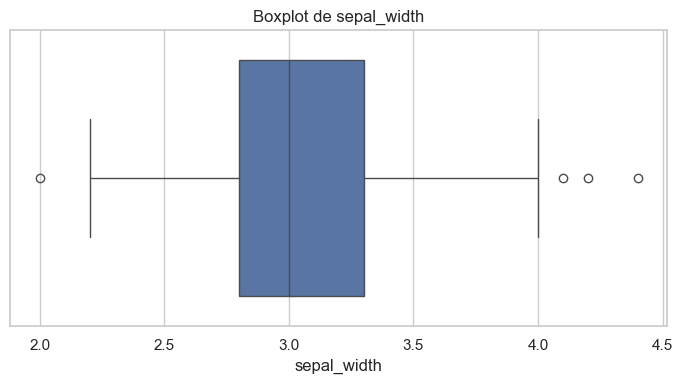

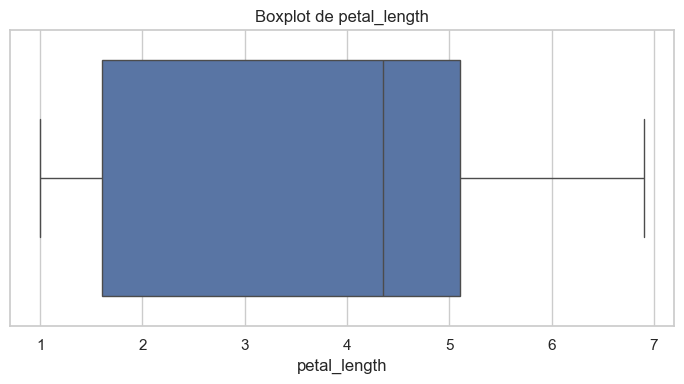

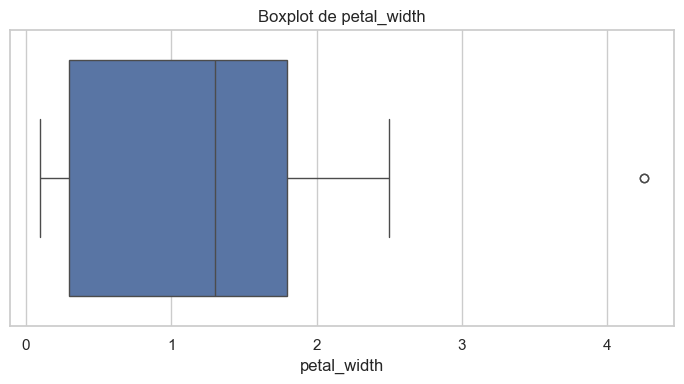

In [16]:
for col in ["sepal_length", "sepal_width", "petal_length", "petal_width"]:
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=df_eda, x=col)
    plt.title(f"Boxplot de {col}")
    plt.tight_layout()
    plt.show()

In [17]:
# Regla IQR para detectar outliers en sepal_length
q1 = df_eda["sepal_length"].quantile(0.25)
q3 = df_eda["sepal_length"].quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outliers_sepal_length = df_eda[(df_eda["sepal_length"] < lower) | (df_eda["sepal_length"] > upper)]
outliers_sepal_length[["sepal_length", "species", "observation_date"]]

,sepal_length,species,observation_date
11,14.220,setosa,2024-01-12
27,14.220,setosa,2024-01-28


## 10. Relaciones entre variables numéricas

Una parte central del EDA es ver cómo se relacionan las variables entre sí.

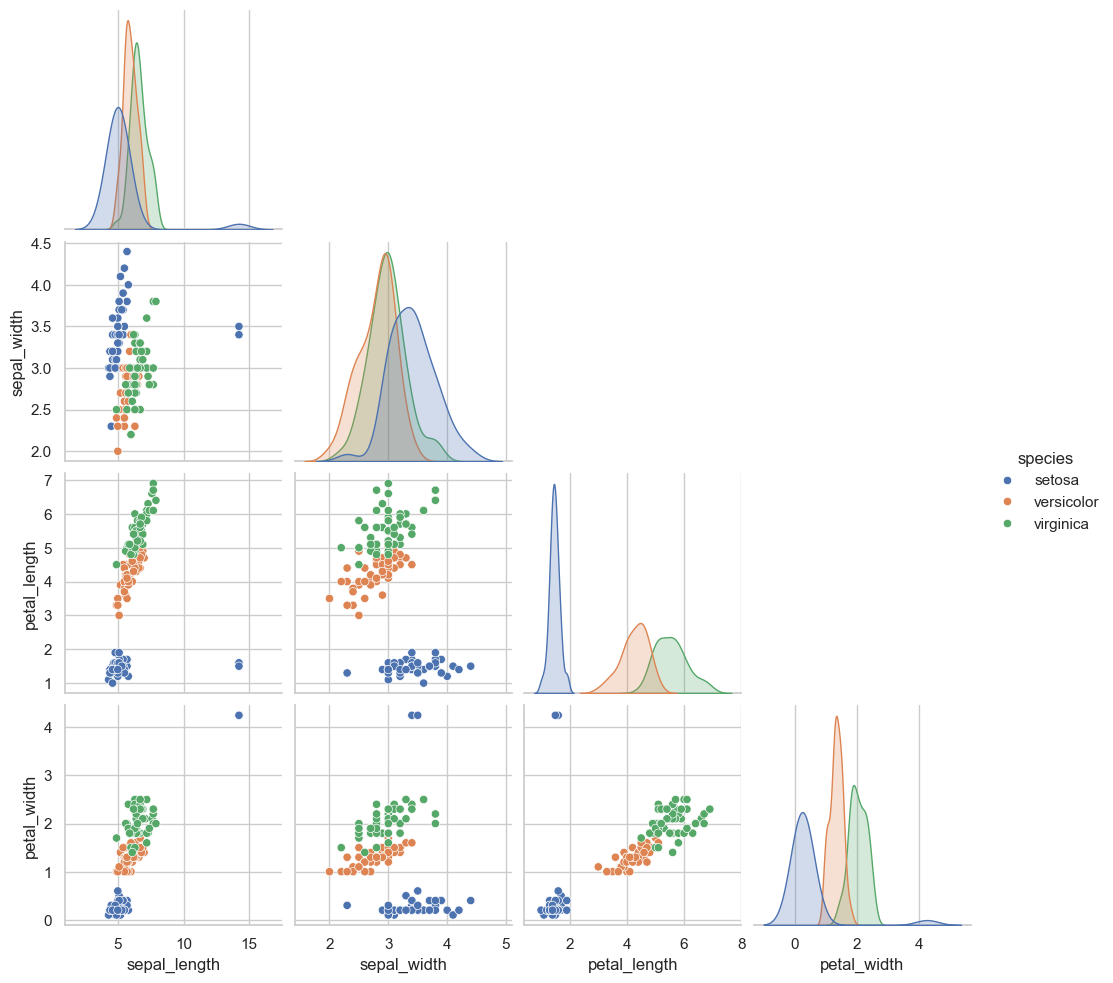

In [18]:
sns.pairplot(
    df_eda[["sepal_length", "sepal_width", "petal_length", "petal_width", "species"]],
    hue="species",
    corner=True
)
plt.show()

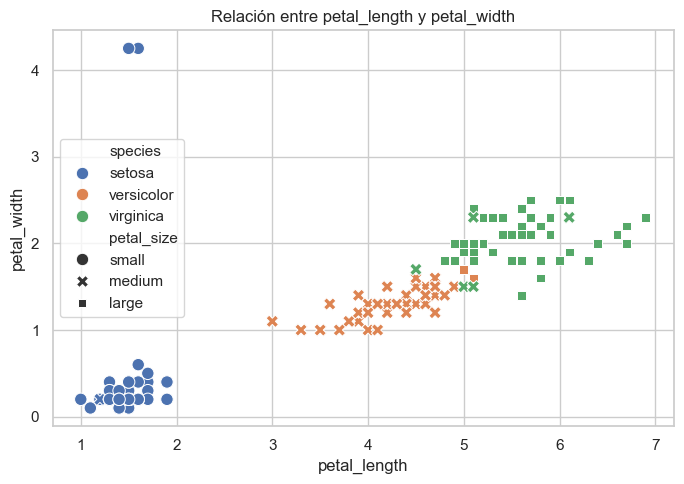

In [19]:
plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=df_eda,
    x="petal_length",
    y="petal_width",
    hue="species",
    style="petal_size",
    s=80
)
plt.title("Relación entre petal_length y petal_width")
plt.tight_layout()
plt.show()

### Qué mirar aquí
- separaciones claras entre grupos
- relaciones lineales o no lineales
- concentraciones
- solapamiento entre clases

## 11. Relaciones categórica vs numérica

Otra parte muy útil del EDA es comparar distribuciones numéricas entre grupos.

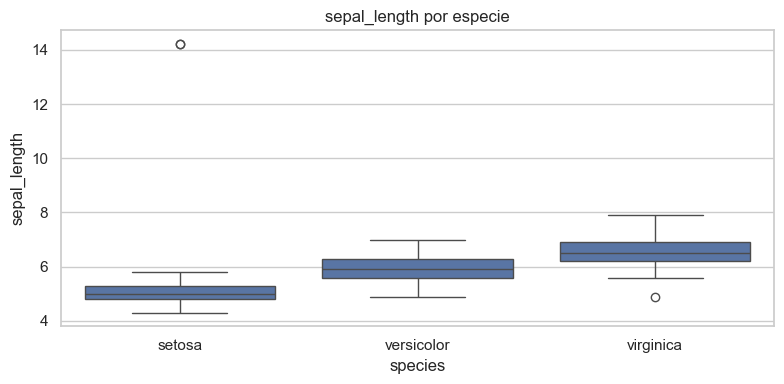

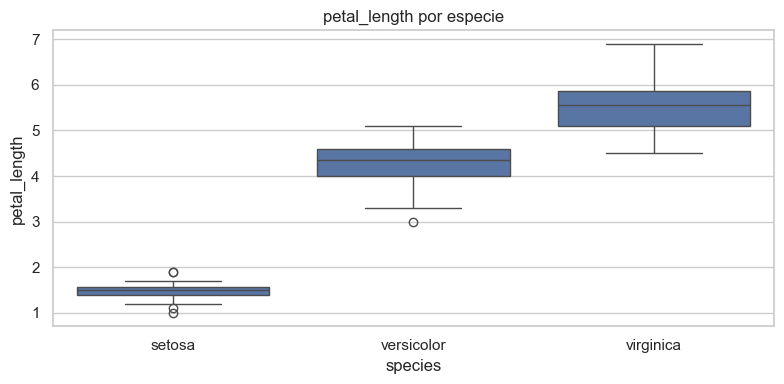

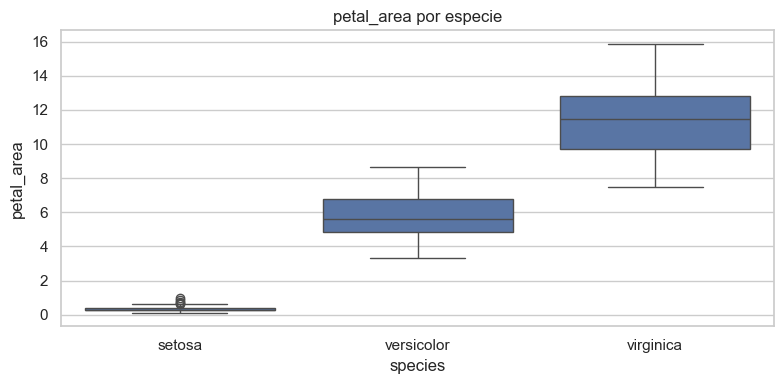

In [20]:
for col in ["sepal_length", "petal_length", "petal_area"]:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df_eda, x="species", y=col)
    plt.title(f"{col} por especie")
    plt.tight_layout()
    plt.show()

In [21]:
summary_by_species = (
    df_eda.groupby("species")[["sepal_length", "sepal_width", "petal_length", "petal_width", "petal_area"]]
          .agg(["mean", "median", "std"])
)

summary_by_species

sepal_length              sepal_width              petal_length  \
                   mean median   std        mean median   std         mean   
species                                                                      
setosa            5.375  5.000 1.857       3.406  3.400 0.387        1.462   
versicolor        5.936  5.900 0.516       2.796  2.900 0.307        4.260   
virginica         6.588  6.500 0.636       2.980  3.000 0.318        5.552   

                        petal_width              petal_area               
           median   std        mean median   std       mean median   std  
species                                                                   
setosa      1.500 0.174       0.408  0.200 0.799      0.366  0.300 0.181  
versicolor  4.350 0.470       1.326  1.300 0.198      5.720  5.615 1.368  
virginica   5.550 0.552       2.026  2.000 0.275     11.296 11.445 2.157

## 12. Correlaciones

La correlación ayuda a detectar variables que se mueven juntas, pero **no implica causalidad**.

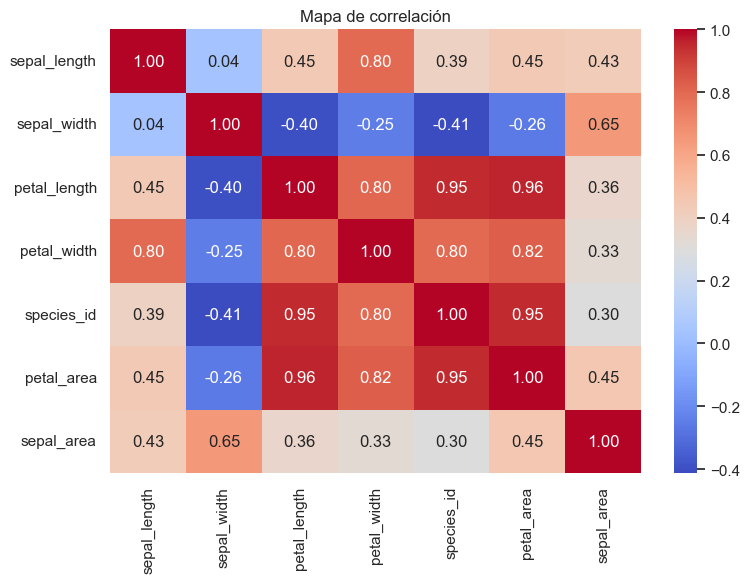

In [22]:
corr = df_eda[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Mapa de correlación")
plt.tight_layout()
plt.show()

### Qué interpretar aquí
- correlaciones fuertes positivas o negativas
- posibles redundancias
- variables candidatas para transformación o reducción de dimensionalidad

## 13. Transformaciones útiles después del EDA

Luego del análisis exploratorio, suele ser necesario:

- imputar
- escalar
- transformar distribuciones
- crear nuevas variables
- reducir dimensionalidad

In [23]:
df_model = df_eda.copy()

features = ["sepal_length", "sepal_width", "petal_length", "petal_width", "petal_area", "sepal_area"]
X = df_model[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=[f"{c}_scaled" for c in features])
X_scaled_df.head()

,sepal_length_scaled,sepal_width_scaled,petal_length_scaled,petal_width_scaled,petal_area_scaled,sepal_area_scaled
0,-0.687,-0.144,-1.340,-1.273,-1.174,0.008
1,-0.845,-0.144,-1.340,-1.273,-1.174,-0.932
2,-1.004,0.330,-1.397,-1.273,-1.178,-0.831
3,-1.083,0.093,-1.283,-1.273,-1.170,-1.063
4,-0.766,1.278,-1.340,-1.273,-1.174,0.053


## 14. Ejemplo de reducción de dimensionalidad con PCA

No es obligatorio en todo EDA, pero sirve para resumir información y visualizar estructura.

In [24]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["species"] = df_model["species"].values

print("Varianza explicada por componente:")
print(pca.explained_variance_ratio_)

Varianza explicada por componente:
[0.57358498 0.28310323]


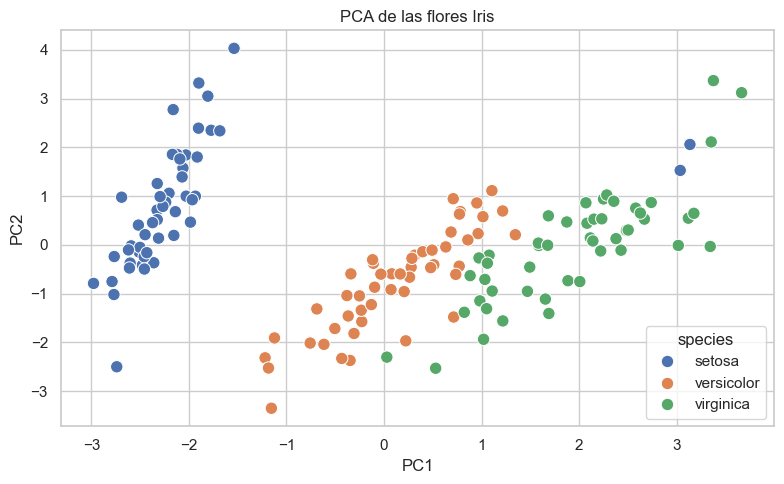

In [25]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="species", s=80)
plt.title("PCA de las flores Iris")
plt.tight_layout()
plt.show()

## 15. Qué debe mostrar un buen EDA

Hasta acá, un buen EDA debería dejar claro:

- cómo son los datos
- qué problemas de calidad existen
- cómo se distribuyen las variables
- qué relaciones aparecen
- qué transformaciones conviene hacer
- qué hallazgos valen la pena comunicar

## 16. Hallazgos principales de este análisis

Ejemplo de resumen ejecutivo:

In [ ]:
hallazgos = [
    "El dataset original es bastante limpio, pero en este ejercicio se simularon faltantes, duplicados y outliers para practicar un EDA realista.",
    "Las variables de pétalo separan mejor las especies que las variables de sépalo.",
    "Existe una relación fuerte entre petal_length, petal_width y petal_area.",
    "Los boxplots muestran diferencias claras entre especies, especialmente en variables de pétalo.",
    "La imputación simple y la eliminación de duplicados resolvieron la mayor parte de los problemas de calidad.",
    "PCA muestra una separación clara entre grupos, por lo que el dataset es prometedor para clasificación."
]

for i, h in enumerate(hallazgos, start=1):
    print(f"{i}. {h}")

## 17. Estructura recomendada para presentar un EDA

Cuando presentes tu análisis, puedes seguir esta secuencia:

1. objetivo del análisis  
2. descripción del dataset  
3. revisión de calidad  
4. análisis univariado  
5. análisis bivariado o multivariado  
6. hallazgos principales  
7. siguientes pasos

## 18. Errores comunes que conviene evitar

- mostrar muchas gráficas sin mensaje
- no revisar calidad de datos
- usar visualizaciones difíciles de leer
- sacar conclusiones muy rápido
- confundir correlación con causalidad
- no conectar el EDA con el objetivo del problema

## 19. Siguientes pasos después del EDA

Dependiendo del caso, después del EDA podríamos:

- construir un modelo predictivo
- segmentar observaciones
- diseñar nuevas variables
- preparar un dashboard
- documentar hallazgos para negocio

## 20. Cierre

El EDA no es solo "hacer gráficas".  
Es el proceso de convertir un dataset en entendimiento.

Un buen EDA:
- mejora la calidad del análisis
- orienta decisiones de modelado
- ayuda a comunicar hallazgos con claridad